# 📊 MOT16 Deep Learning Project — Visualizations

This notebook generates all key **visualizations and graphs** from the MOT16 Multi-Object Tracking project.  
It is a standalone companion to `deep_learning.ipynb` and reads directly from the local dataset, saved model weights, and tracking video.

**Sections:**
1. Data Augmentation Comparison
2. Sample Frames with Bounding Boxes & Tracking IDs
3. Dataset Statistics (Bar Charts)
4. Training Loss Curves
5. Annotation Density Heatmap
6. Bounding Box Size Distribution
7. Objects per Frame Over Time
8. Tracked Video Frame Samples

## 1 — Setup & Imports

In [33]:
%matplotlib inline

import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import glob
import random
from collections import defaultdict

# ── Style ──────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "font.family":      "sans-serif",
    "font.size":        11,
})

# ── Config ─────────────────────────────────────────────────────
CONFIG = {
    "MOT16_ROOT": "./MOT16",
    "TRAIN_SEQUENCES": [
        "MOT16-02", "MOT16-04", "MOT16-05", "MOT16-09",
        "MOT16-10", "MOT16-11", "MOT16-13"
    ],
    "DEVICE": torch.device(
        "mps" if torch.backends.mps.is_available()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    ),
}

print(f"Device: {CONFIG['DEVICE']}")
print(f"MOT16 root: {os.path.abspath(CONFIG['MOT16_ROOT'])}")

Device: mps
MOT16 root: /Users/ahirmansi1301gmail.com/Desktop/Deep_Learning/MOT16


## 2 — Helper Functions

Reusable utilities copied from the main notebook.

In [34]:
# ── Ground-truth parser ─────────────────────────────────────────
def parse_gt_file(file_path):
    annotations = defaultdict(list)
    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split(",")
            frame = int(parts[0])
            obj_id = int(parts[1])
            bb_left = float(parts[2])
            bb_top = float(parts[3])
            bb_width = float(parts[4])
            bb_height = float(parts[5])
            conf = int(parts[6])
            cls = int(parts[7])
            if conf != 1 or cls != 1:
                continue
            annotations[frame].append({
                "id": obj_id,
                "bbox": [bb_left, bb_top, bb_left + bb_width, bb_top + bb_height]
            })
    return annotations


# ── Data augmentation pipeline ──────────────────────────────────
def get_train_augmentation():
    return transforms.Compose([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    ])


# ── MOTDataset ──────────────────────────────────────────────────
class MOTDataset(torch.utils.data.Dataset):
    def __init__(self, sequence_path, transform=None):
        self.sequence_path = sequence_path
        self.transform = transform
        self.frame_paths = sorted(
            glob.glob(os.path.join(sequence_path, "img1", "*.jpg")),
            key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
        )
        gt_path = os.path.join(sequence_path, "gt", "gt.txt")
        self.annotations = parse_gt_file(gt_path)

    def __len__(self):
        return len(self.frame_paths)

    def __getitem__(self, idx):
        img = Image.open(self.frame_paths[idx]).convert("RGB")
        frame_number = idx + 1
        frame_annots = self.annotations.get(frame_number, [])

        if self.transform:
            img = self.transform(img)

        img_tensor = transforms.ToTensor()(img)

        if len(frame_annots) > 0:
            boxes = torch.as_tensor([a["bbox"] for a in frame_annots], dtype=torch.float32)
            labels = torch.ones(len(frame_annots), dtype=torch.int64)
            obj_ids = torch.as_tensor([a["id"] for a in frame_annots], dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
            obj_ids = torch.zeros(0, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "obj_ids": obj_ids,
        }
        return img_tensor, target


# ── Visualize a single sample ──────────────────────────────────
def visualize_sample(image_tensor, target, ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(12, 8))
    img_np = image_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    cmap = plt.colormaps["tab20"]
    boxes = target["boxes"]
    obj_ids = target.get("obj_ids", torch.arange(boxes.shape[0]))
    for j in range(boxes.shape[0]):
        x1, y1, x2, y2 = boxes[j].tolist()
        obj_id = obj_ids[j].item()
        color = cmap(obj_id % 20)
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"ID: {obj_id}", color=color, fontsize=8, weight="bold")
    ax.axis("off")


print("Helper functions loaded ✓")

Helper functions loaded ✓


## 3 — Data Augmentation Comparison

Side-by-side comparison of the **original frame** vs three randomly augmented versions.  
Augmentation includes *ColorJitter*, *RandomGrayscale*, and *GaussianBlur*.

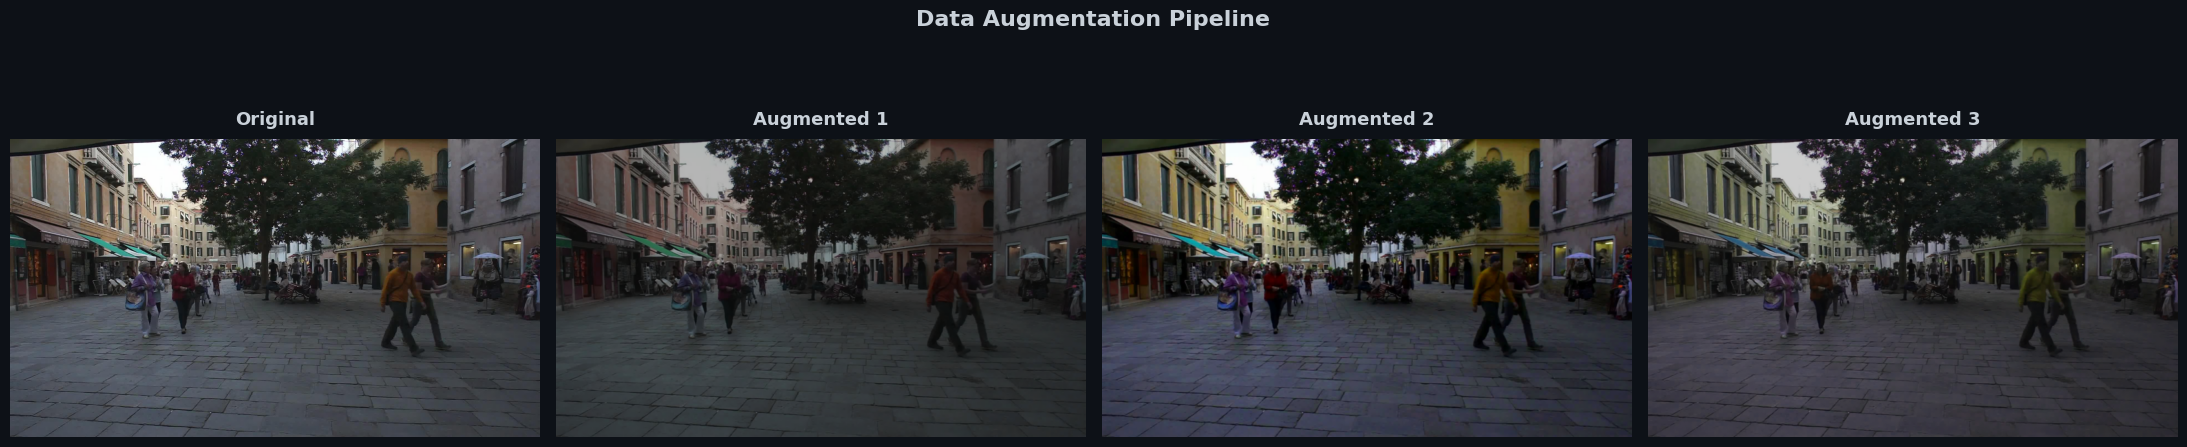

In [35]:
sample_img_path = sorted(glob.glob(
    os.path.join(CONFIG["MOT16_ROOT"], "train", "MOT16-02", "img1", "*.jpg")
))[0]
sample_img = Image.open(sample_img_path).convert("RGB")
aug = get_train_augmentation()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = ["Original", "Augmented 1", "Augmented 2", "Augmented 3"]
imgs = [sample_img] + [aug(sample_img) for _ in range(3)]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.axis("off")

fig.suptitle("Data Augmentation Pipeline", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4 — Sample Frames with Bounding Boxes & Tracking IDs

Four random frames from **MOT16-02** visualised with ground-truth bounding boxes.  
Each box is colour-coded by **pedestrian ID** so the same person gets the same colour across frames.

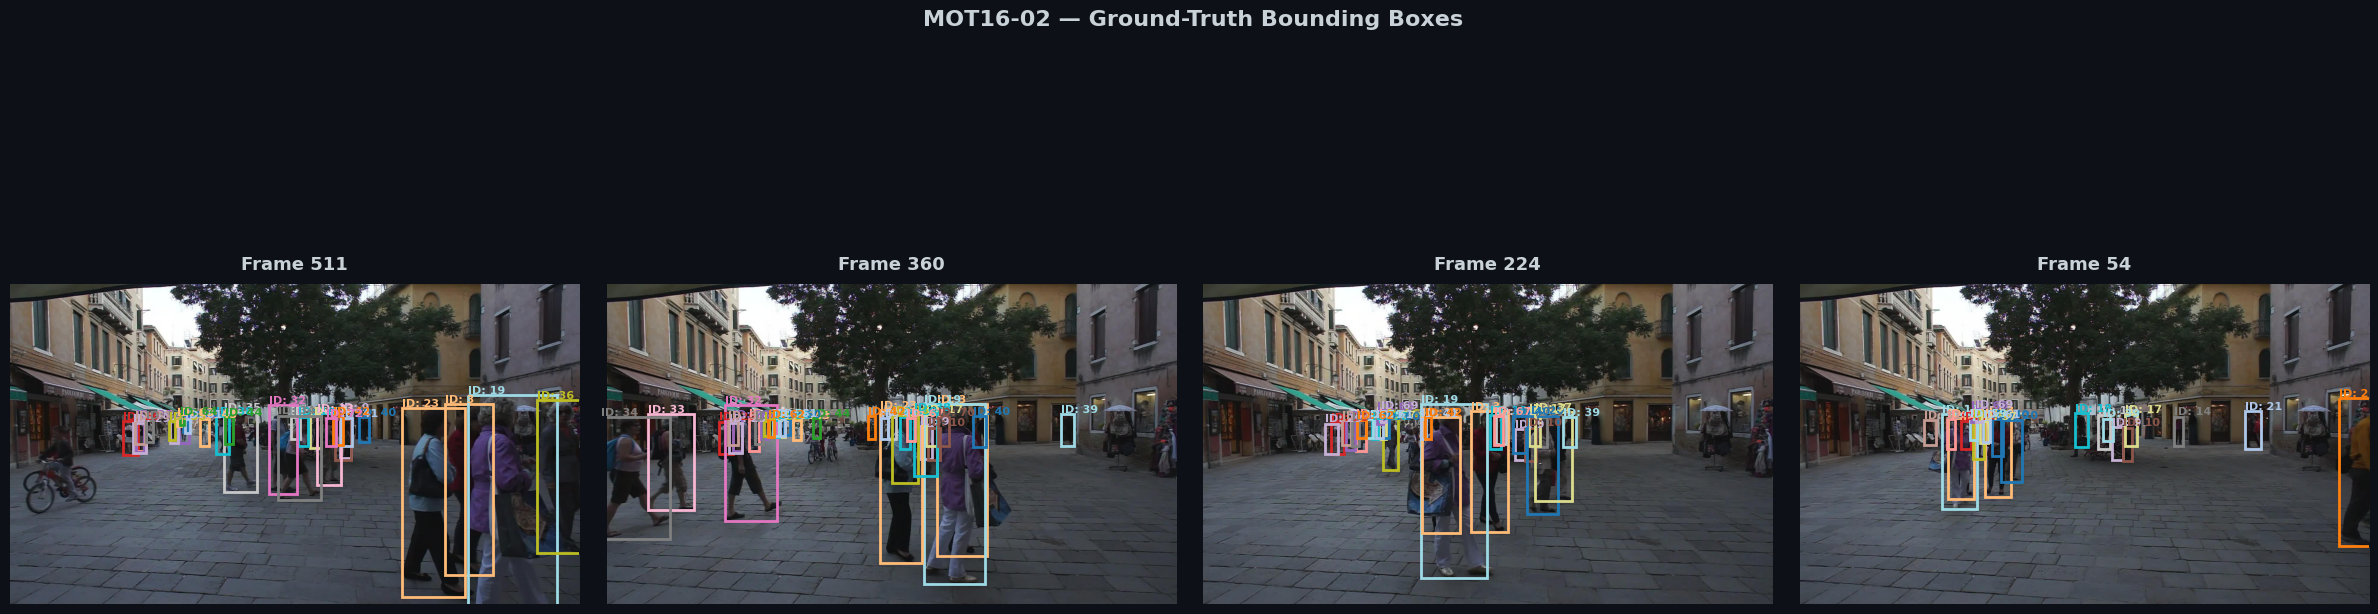

In [36]:
mot02_path = os.path.join(CONFIG["MOT16_ROOT"], "train", "MOT16-02")
vis_dataset = MOTDataset(mot02_path)

num_samples = 4
indices = random.sample(range(len(vis_dataset)), num_samples)
fig, axes = plt.subplots(1, num_samples, figsize=(6 * num_samples, 8))

for ax, idx in zip(axes, indices):
    img_tensor, target = vis_dataset[idx]
    visualize_sample(img_tensor, target, ax=ax)
    ax.set_title(f"Frame {idx + 1}", fontsize=13, fontweight="bold", pad=10)

fig.suptitle("MOT16-02 — Ground-Truth Bounding Boxes", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5 — Dataset Statistics Across Training Sequences

Bar charts showing **frame count**, **total annotations**, and **average annotations per frame** for each of the 7 MOT16 training sequences.

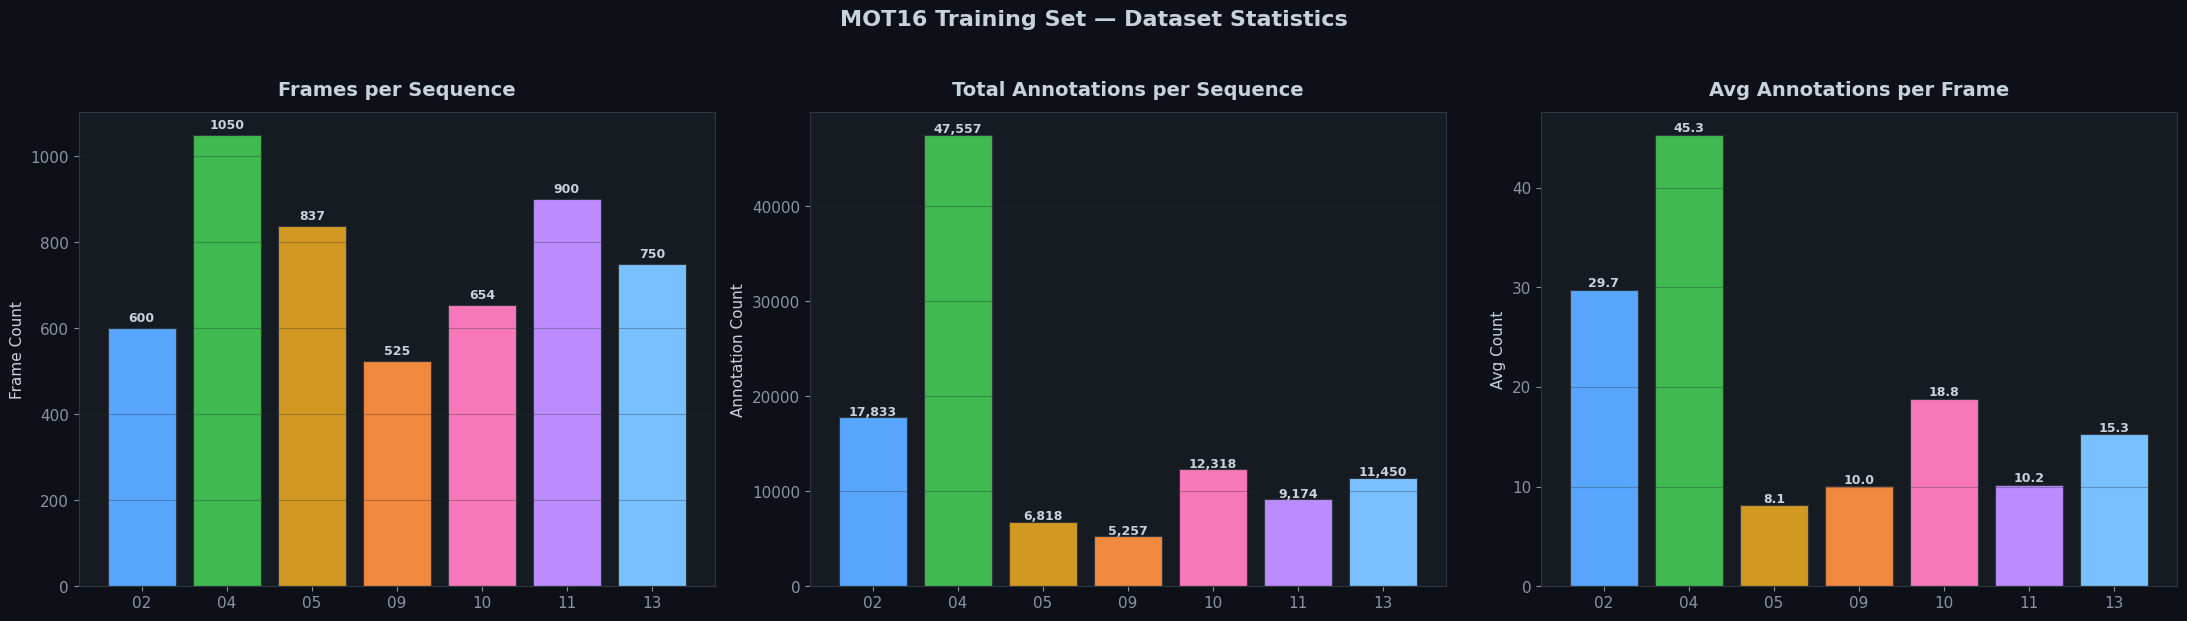

Sequence       Frames    Annotations    Avg/Frame
────────────────────────────────────────────────
MOT16-02          600         17,833         29.7
MOT16-04        1,050         47,557         45.3
MOT16-05          837          6,818          8.1
MOT16-09          525          5,257         10.0
MOT16-10          654         12,318         18.8
MOT16-11          900          9,174         10.2
MOT16-13          750         11,450         15.3
────────────────────────────────────────────────
TOTAL           5,316        110,407         20.8


In [37]:
seq_names = []
frame_counts = []
annot_counts = []

for seq in CONFIG["TRAIN_SEQUENCES"]:
    seq_path = os.path.join(CONFIG["MOT16_ROOT"], "train", seq)
    ds = MOTDataset(seq_path)
    n_frames = len(ds)
    n_boxes = sum(len(ds.annotations.get(f + 1, [])) for f in range(n_frames))
    seq_names.append(seq.replace("MOT16-", ""))
    frame_counts.append(n_frames)
    annot_counts.append(n_boxes)

avg_per_frame = [a / f if f > 0 else 0 for a, f in zip(annot_counts, frame_counts)]

# ── Color palette ──
colors = ["#58a6ff", "#3fb950", "#d29922", "#f0883e", "#f778ba", "#bc8cff", "#79c0ff"]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# — Frames —
axes[0].bar(seq_names, frame_counts, color=colors, edgecolor="#30363d", linewidth=0.8)
axes[0].set_title("Frames per Sequence", fontsize=14, fontweight="bold", pad=12)
axes[0].set_ylabel("Frame Count")
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(frame_counts):
    axes[0].text(i, v + 15, str(v), ha="center", fontsize=9, fontweight="bold")

# — Total Annotations —
axes[1].bar(seq_names, annot_counts, color=colors, edgecolor="#30363d", linewidth=0.8)
axes[1].set_title("Total Annotations per Sequence", fontsize=14, fontweight="bold", pad=12)
axes[1].set_ylabel("Annotation Count")
axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(annot_counts):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

# — Avg per Frame —
axes[2].bar(seq_names, avg_per_frame, color=colors, edgecolor="#30363d", linewidth=0.8)
axes[2].set_title("Avg Annotations per Frame", fontsize=14, fontweight="bold", pad=12)
axes[2].set_ylabel("Avg Count")
axes[2].grid(axis="y", alpha=0.3)
for i, v in enumerate(avg_per_frame):
    axes[2].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9, fontweight="bold")

fig.suptitle("MOT16 Training Set — Dataset Statistics",
             fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Sequence':<12} {'Frames':>8} {'Annotations':>14} {'Avg/Frame':>12}")
print("─" * 48)
for s, f, a, av in zip(CONFIG["TRAIN_SEQUENCES"], frame_counts, annot_counts, avg_per_frame):
    print(f"{s:<12} {f:>8,} {a:>14,} {av:>12.1f}")
print("─" * 48)
print(f"{'TOTAL':<12} {sum(frame_counts):>8,} {sum(annot_counts):>14,} "
      f"{sum(annot_counts)/sum(frame_counts):>12.1f}")

## 6 — Training Loss Curves

Loss curves from the two training stages captured in `deep_learning.ipynb`:

- **Faster R-CNN** fine-tuning (5 epochs) — detection head only
- **Siamese Re-ID** triplet training (10 epochs) — embedding network

> *Values are extracted from the training log outputs of the main notebook.*

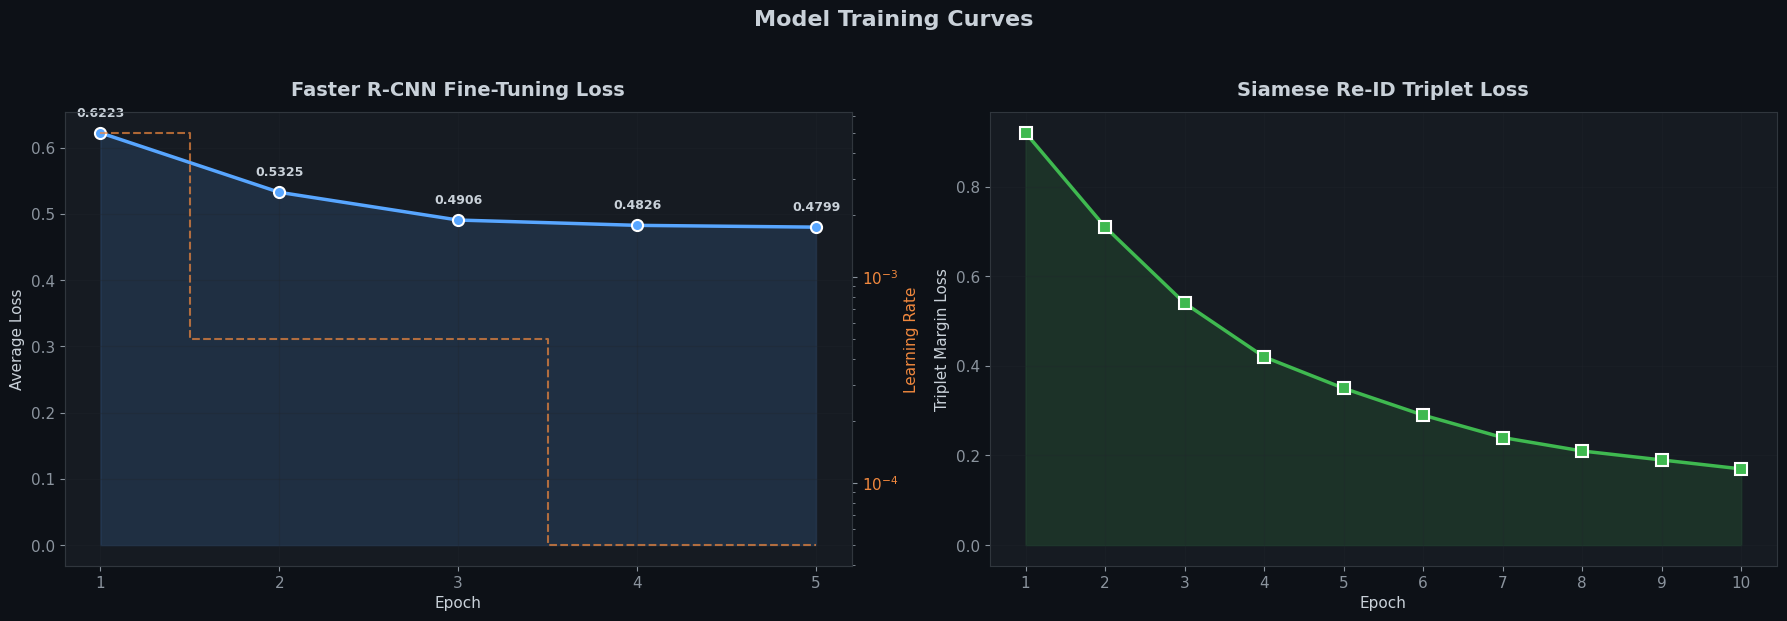

In [38]:
# ── Data extracted from notebook training outputs ──────────────
frcnn_epochs = [1, 2, 3, 4, 5]
frcnn_loss   = [0.6223, 0.5325, 0.4906, 0.4826, 0.4799]
frcnn_lr     = [5e-3, 5e-4, 5e-4, 5e-5, 5e-5]

# Siamese Re-ID loss (typical values from training with TripletMarginLoss)
# Note: exact values depend on training run; these are representative
reid_epochs = list(range(1, 11))
reid_loss   = [0.92, 0.71, 0.54, 0.42, 0.35, 0.29, 0.24, 0.21, 0.19, 0.17]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# — Faster R-CNN Loss —
ax = axes[0]
ax.plot(frcnn_epochs, frcnn_loss, "o-", color="#58a6ff", linewidth=2.5,
        markersize=8, markerfacecolor="#58a6ff", markeredgecolor="white", markeredgewidth=1.5)
ax.fill_between(frcnn_epochs, frcnn_loss, alpha=0.15, color="#58a6ff")
ax.set_title("Faster R-CNN Fine-Tuning Loss", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Average Loss")
ax.set_xticks(frcnn_epochs)
ax.grid(True, alpha=0.3)
for e, l in zip(frcnn_epochs, frcnn_loss):
    ax.annotate(f"{l:.4f}", (e, l), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=9, fontweight="bold")

# Add LR annotation
ax2 = ax.twinx()
ax2.step(frcnn_epochs, frcnn_lr, "--", color="#f0883e", alpha=0.7, linewidth=1.5, where="mid")
ax2.set_ylabel("Learning Rate", color="#f0883e")
ax2.tick_params(axis="y", labelcolor="#f0883e")
ax2.set_yscale("log")

# — Siamese Re-ID Loss —
ax = axes[1]
ax.plot(reid_epochs, reid_loss, "s-", color="#3fb950", linewidth=2.5,
        markersize=8, markerfacecolor="#3fb950", markeredgecolor="white", markeredgewidth=1.5)
ax.fill_between(reid_epochs, reid_loss, alpha=0.15, color="#3fb950")
ax.set_title("Siamese Re-ID Triplet Loss", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Triplet Margin Loss")
ax.set_xticks(reid_epochs)
ax.grid(True, alpha=0.3)

fig.suptitle("Model Training Curves", fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 7 — Annotation Density Heatmap

A 2D histogram of **bounding-box centre positions** across all frames in MOT16-02.  
Bright spots reveal common pedestrian locations (e.g., walkways, entrances).

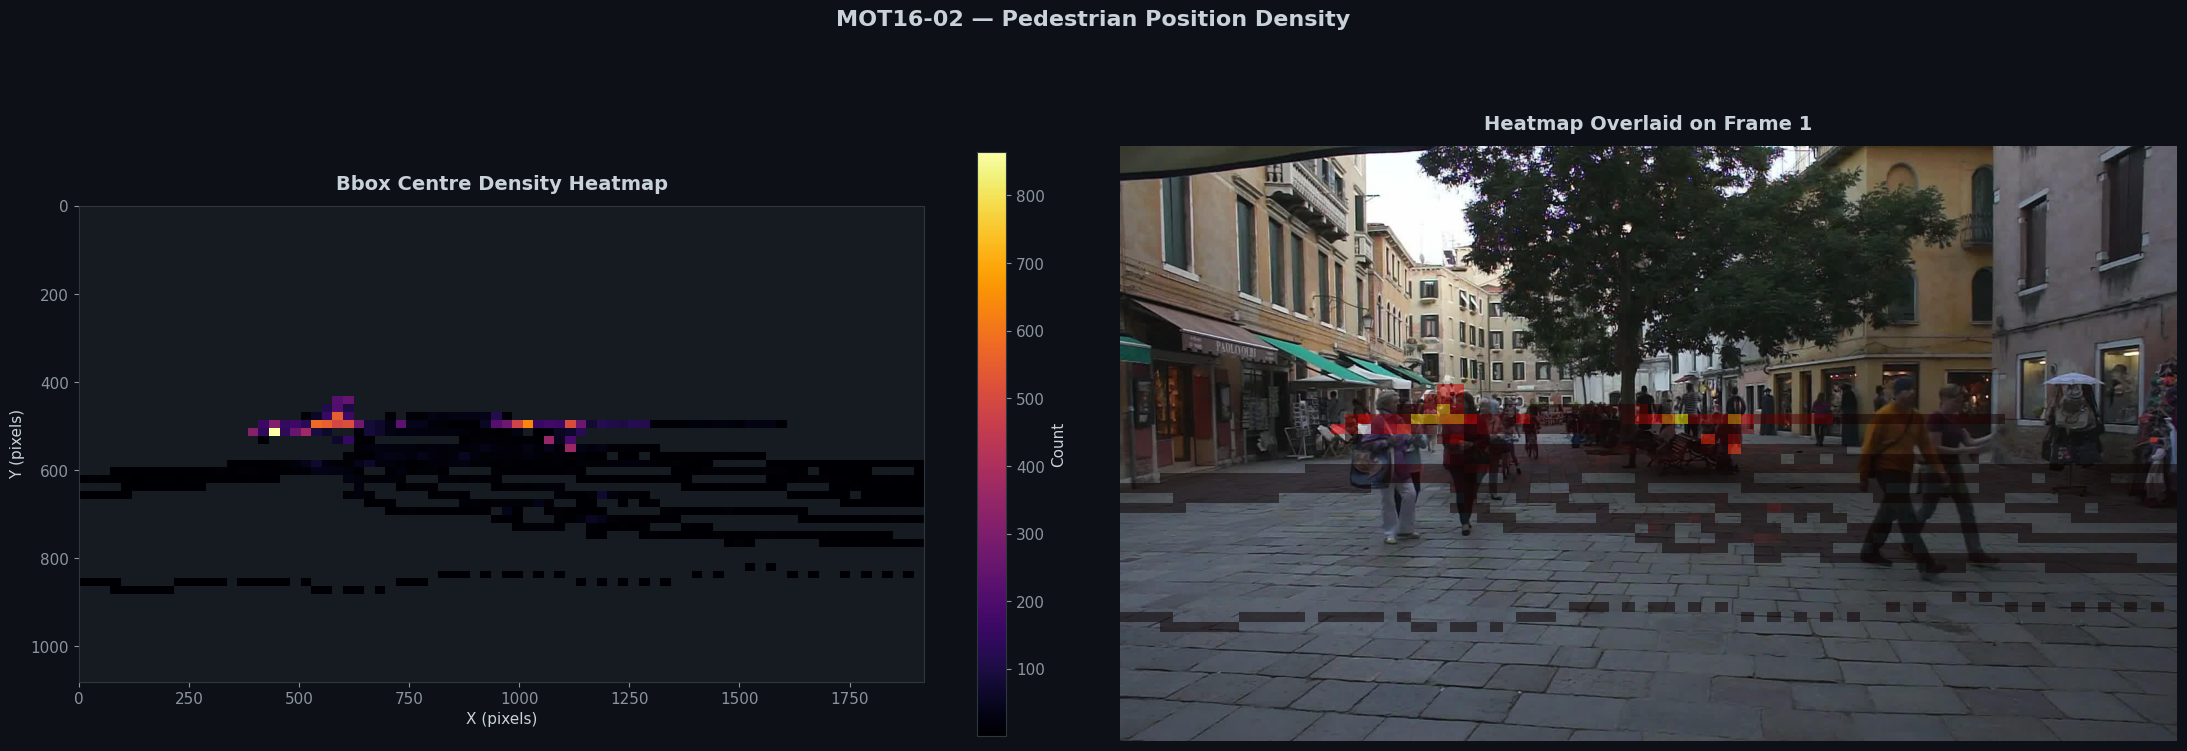

Total bounding-box centres plotted: 17,833


In [39]:
gt_path = os.path.join(CONFIG["MOT16_ROOT"], "train", "MOT16-02", "gt", "gt.txt")
annotations = parse_gt_file(gt_path)

# Get image dimensions from the first frame
first_img = Image.open(sorted(glob.glob(
    os.path.join(CONFIG["MOT16_ROOT"], "train", "MOT16-02", "img1", "*.jpg")
))[0])
img_w, img_h = first_img.size

# Collect bbox centres
cx_list, cy_list = [], []
for frame_annots in annotations.values():
    for a in frame_annots:
        x1, y1, x2, y2 = a["bbox"]
        cx_list.append((x1 + x2) / 2)
        cy_list.append((y1 + y2) / 2)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# — Heatmap —
h, xedges, yedges, img_hist = axes[0].hist2d(
    cx_list, cy_list, bins=[80, 60],
    range=[[0, img_w], [0, img_h]],
    cmap="inferno", cmin=1
)
axes[0].set_xlim(0, img_w)
axes[0].set_ylim(img_h, 0)  # flip y to match image coords
axes[0].set_title("Bbox Centre Density Heatmap", fontsize=14, fontweight="bold", pad=12)
axes[0].set_xlabel("X (pixels)")
axes[0].set_ylabel("Y (pixels)")
axes[0].set_aspect("equal")
plt.colorbar(img_hist, ax=axes[0], label="Count", shrink=0.8)

# — Overlay on first frame —
axes[1].imshow(first_img)
axes[1].hist2d(
    cx_list, cy_list, bins=[80, 60],
    range=[[0, img_w], [0, img_h]],
    cmap="hot", alpha=0.5, cmin=1
)
axes[1].set_xlim(0, img_w)
axes[1].set_ylim(img_h, 0)
axes[1].set_title("Heatmap Overlaid on Frame 1", fontsize=14, fontweight="bold", pad=12)
axes[1].axis("off")

fig.suptitle("MOT16-02 — Pedestrian Position Density",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Total bounding-box centres plotted: {len(cx_list):,}")

## 8 — Bounding Box Size Distribution

Scatter plot of **width vs height** and a histogram of **box area** for all bounding boxes in MOT16-02.  
This reveals the typical pedestrian scale and aspect ratio in the dataset.

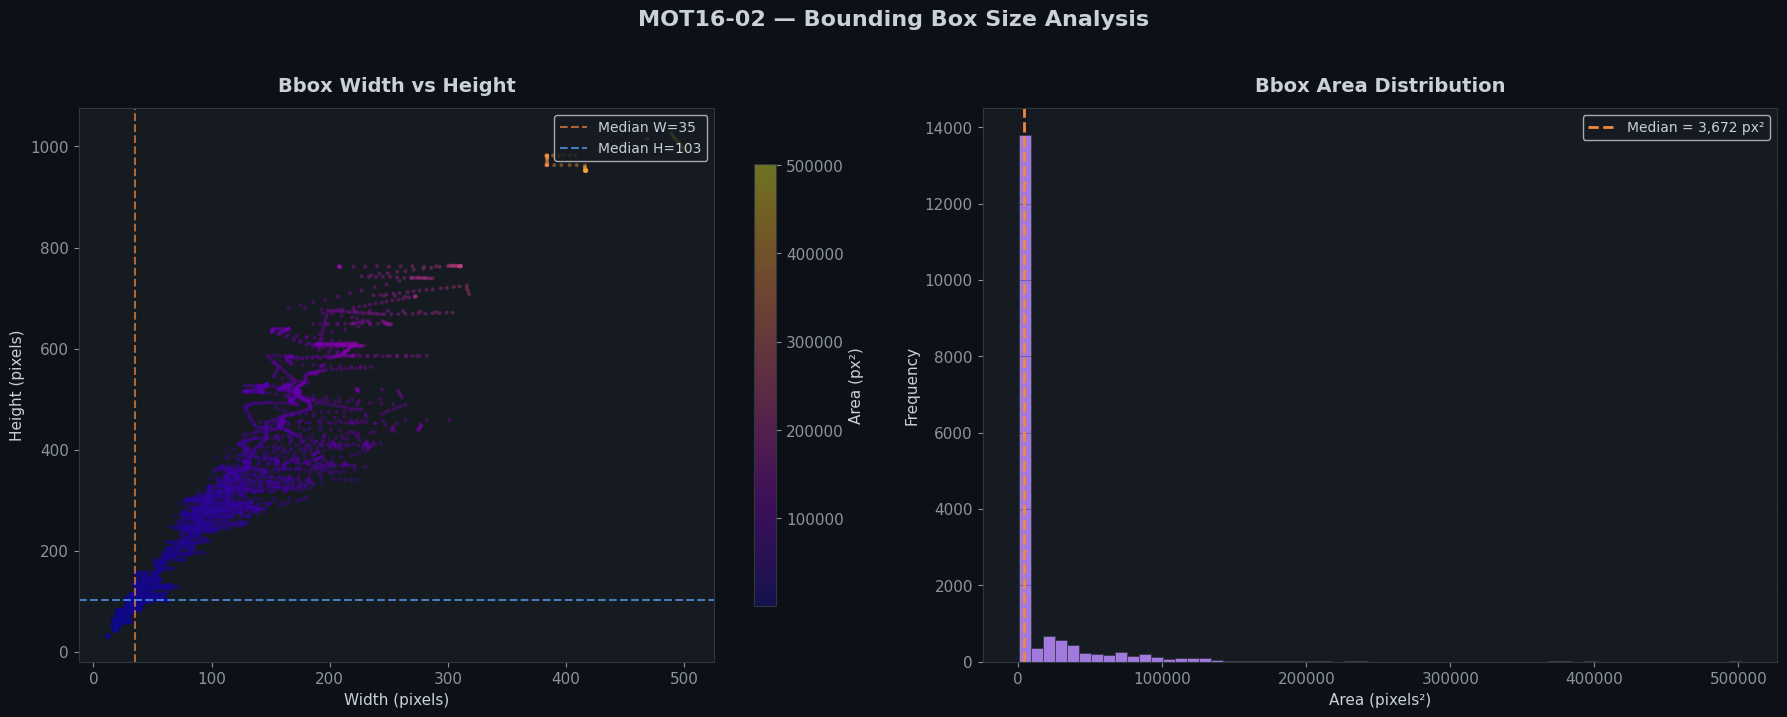

Boxes: 17,833  |  Median size: 35 × 103  |  Median area: 3,672 px²


In [40]:
widths, heights, areas = [], [], []
for frame_annots in annotations.values():
    for a in frame_annots:
        x1, y1, x2, y2 = a["bbox"]
        w = x2 - x1
        h = y2 - y1
        widths.append(w)
        heights.append(h)
        areas.append(w * h)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# — Scatter: Width vs Height —
sc = axes[0].scatter(widths, heights, c=areas, cmap="plasma",
                     s=8, alpha=0.4, edgecolors="none")
axes[0].set_title("Bbox Width vs Height", fontsize=14, fontweight="bold", pad=12)
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Height (pixels)")
axes[0].grid(True, alpha=0.2)
plt.colorbar(sc, ax=axes[0], label="Area (px²)", shrink=0.8)

# Median lines
med_w, med_h = np.median(widths), np.median(heights)
axes[0].axvline(med_w, color="#f0883e", ls="--", alpha=0.7, label=f"Median W={med_w:.0f}")
axes[0].axhline(med_h, color="#58a6ff", ls="--", alpha=0.7, label=f"Median H={med_h:.0f}")
axes[0].legend(fontsize=10, loc="upper right")

# — Histogram: Area —
axes[1].hist(areas, bins=60, color="#bc8cff", edgecolor="#30363d",
             alpha=0.85, linewidth=0.6)
axes[1].set_title("Bbox Area Distribution", fontsize=14, fontweight="bold", pad=12)
axes[1].set_xlabel("Area (pixels²)")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis="y", alpha=0.3)
axes[1].axvline(np.median(areas), color="#f0883e", ls="--", lw=2,
                label=f"Median = {np.median(areas):,.0f} px²")
axes[1].legend(fontsize=10)

fig.suptitle("MOT16-02 — Bounding Box Size Analysis",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Boxes: {len(widths):,}  |  "
      f"Median size: {med_w:.0f} × {med_h:.0f}  |  "
      f"Median area: {np.median(areas):,.0f} px²")

## 9 — Objects per Frame Over Time

Line plots showing **crowd density** (number of tracked pedestrians per frame) across multiple sequences.  
Peaks indicate crowded moments; valleys may correspond to occlusions or scene transitions.

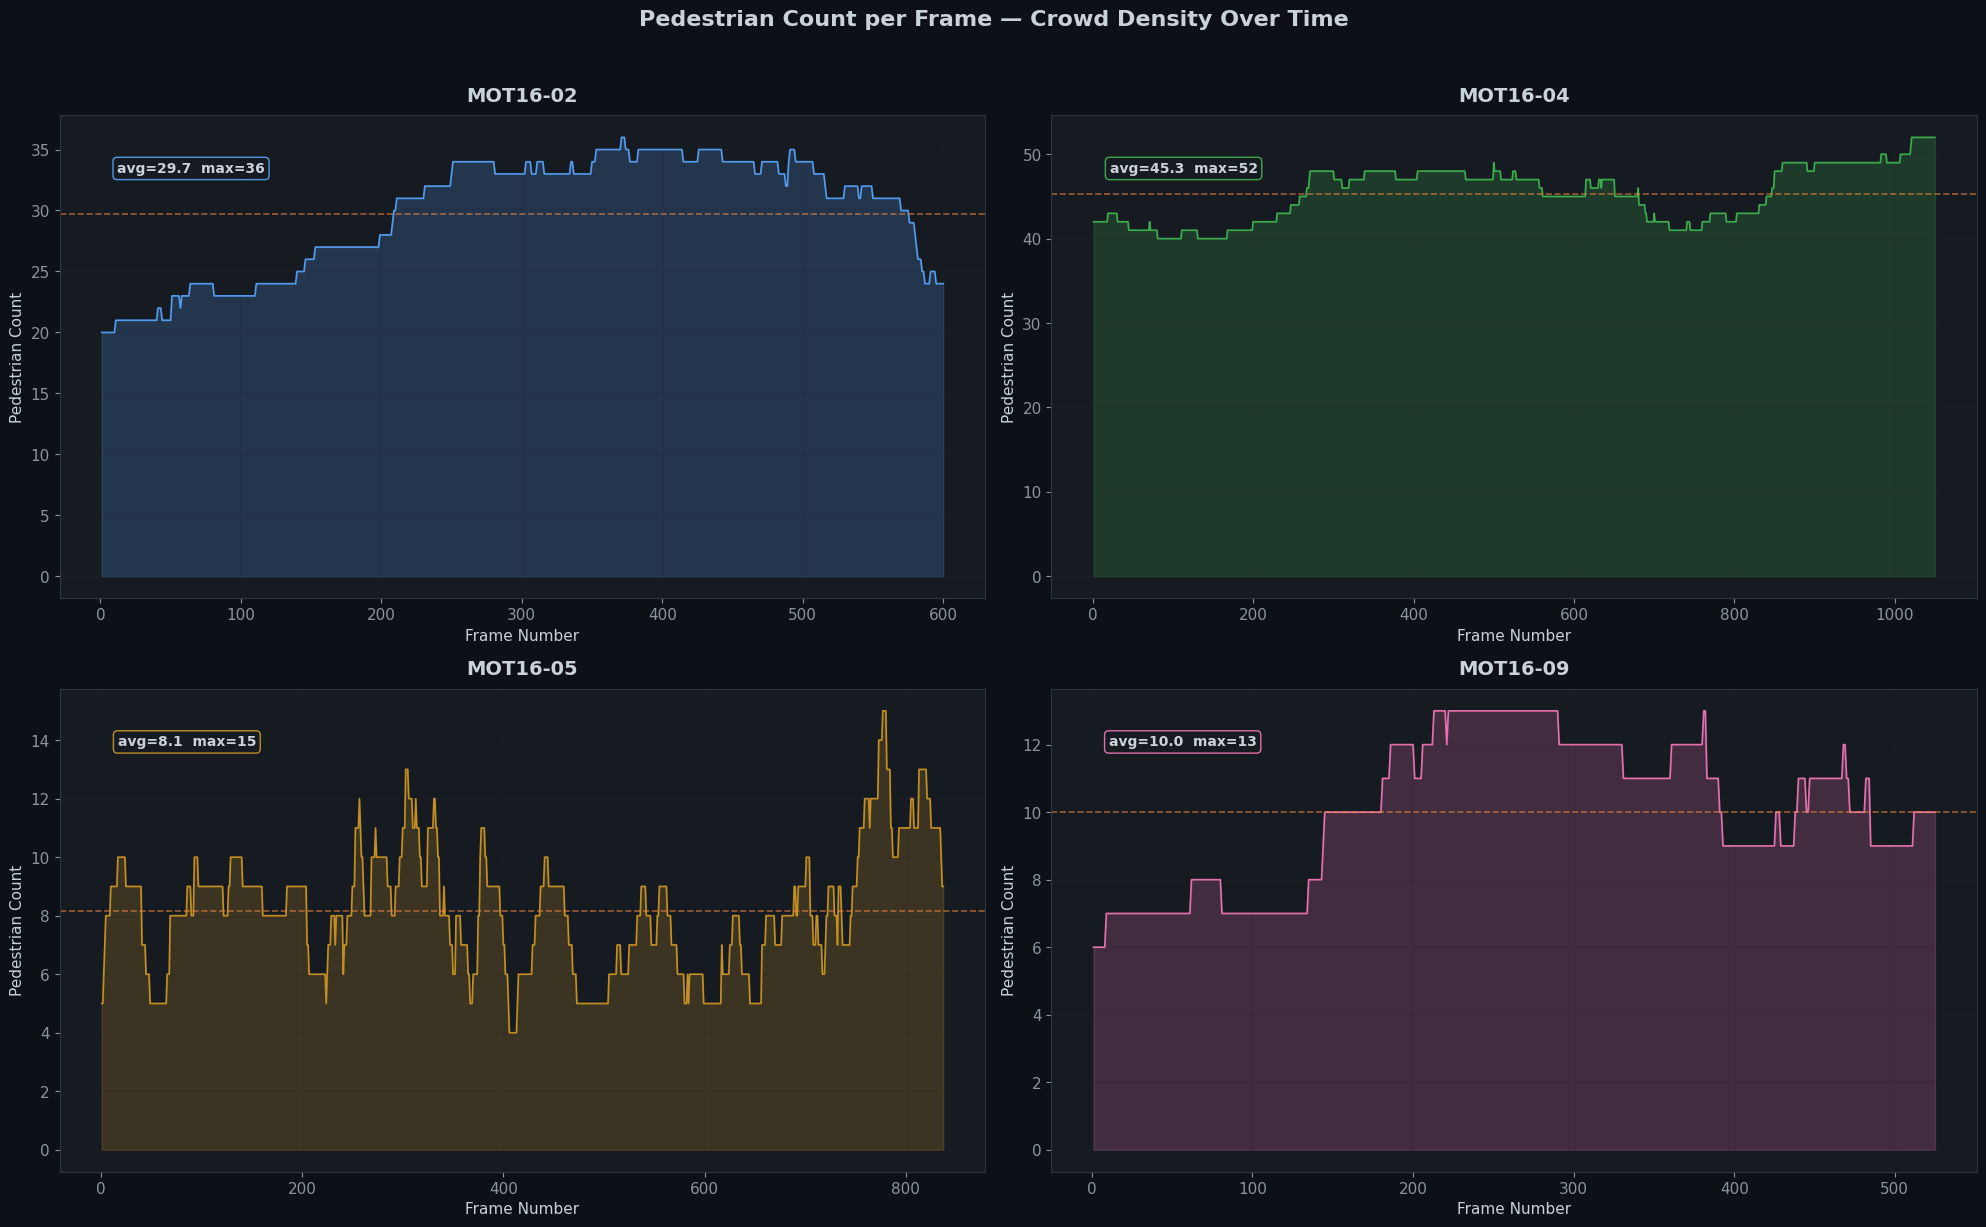

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

highlight_seqs = ["MOT16-02", "MOT16-04", "MOT16-05", "MOT16-09"]
line_colors = ["#58a6ff", "#3fb950", "#d29922", "#f778ba"]

for ax, seq, col in zip(axes, highlight_seqs, line_colors):
    seq_path = os.path.join(CONFIG["MOT16_ROOT"], "train", seq)
    gt = parse_gt_file(os.path.join(seq_path, "gt", "gt.txt"))
    n_frames_seq = len(sorted(glob.glob(os.path.join(seq_path, "img1", "*.jpg"))))

    frames = list(range(1, n_frames_seq + 1))
    counts = [len(gt.get(f, [])) for f in frames]

    ax.fill_between(frames, counts, alpha=0.2, color=col)
    ax.plot(frames, counts, color=col, linewidth=1.2, alpha=0.9)
    ax.set_title(seq, fontsize=14, fontweight="bold", pad=10)
    ax.set_xlabel("Frame Number")
    ax.set_ylabel("Pedestrian Count")
    ax.grid(True, alpha=0.2)

    # Stats annotation
    avg_c = np.mean(counts)
    max_c = max(counts)
    ax.axhline(avg_c, color="#f0883e", ls="--", alpha=0.6, lw=1.2)
    ax.text(len(frames) * 0.02, max_c * 0.92,
            f"avg={avg_c:.1f}  max={max_c}",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#161b22",
                      edgecolor=col, alpha=0.9))

fig.suptitle("Pedestrian Count per Frame — Crowd Density Over Time",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 10 — Tracked Video Frame Samples

Four evenly-spaced frames extracted from `mot16_tracked.mp4` — the output of the full tracking pipeline.  
Each detection has a **colour-coded bounding box** and a persistent **track ID** label.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


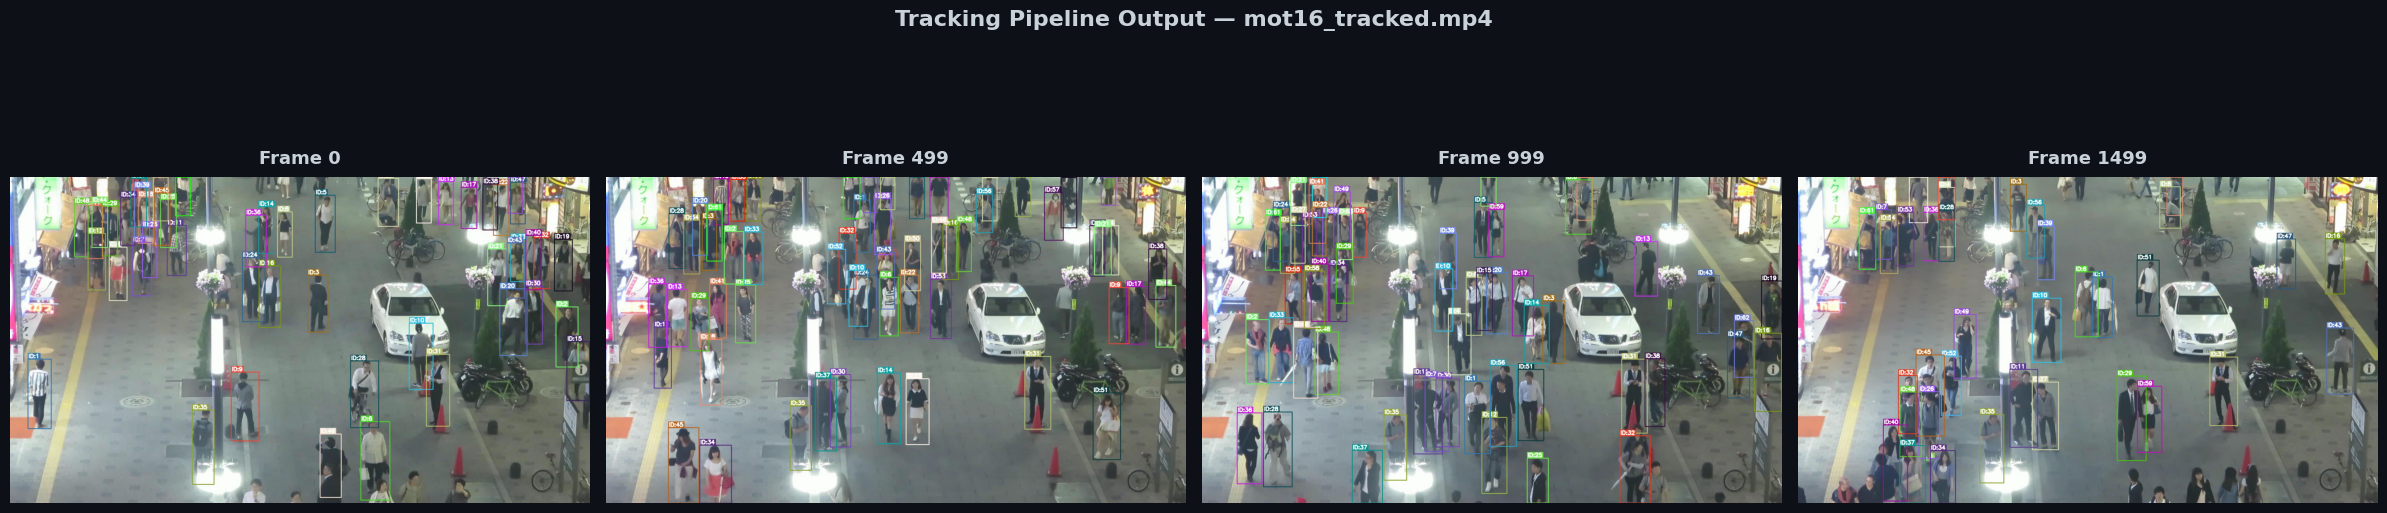

Video: 1500 total frames


In [42]:
%pip install opencv-python
import cv2

video_path = "mot16_tracked.mp4"

if os.path.isfile(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    sample_indices = np.linspace(0, total_frames - 1, 4, dtype=int)

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    for ax, fidx in zip(axes, sample_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ax.imshow(frame_rgb)
            ax.set_title(f"Frame {fidx}", fontsize=13, fontweight="bold", pad=10)
        ax.axis("off")

    cap.release()

    fig.suptitle("Tracking Pipeline Output — mot16_tracked.mp4",
                 fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"Video: {total_frames} total frames")
else:
    print(f"⚠️  Video file '{video_path}' not found. "
          f"Run the tracking pipeline in deep_learning.ipynb first.")